In [1]:
!wget http://bit.ly/3ZLyF82 -O CSS.css -q

from IPython.core.display import HTML

with open("./CSS.css", "r") as file:
    custom_css = file.read()

HTML(custom_css)

In [2]:
print("Total files and folders in the dataset...\n")
!ls ../input/titanic -GFlash --color

Total files and folders in the dataset...

total 96K
   0 drwxr-xr-x 2 nobody    0 Dec  4  2020 ./
4.0K drwxr-xr-x 3 root   4.0K Jun  1 10:35 ../
4.0K -rw-r--r-- 1 nobody 3.2K Dec  4  2020 gender_submission.csv
 28K -rw-r--r-- 1 nobody  28K Dec  4  2020 test.csv
 60K -rw-r--r-- 1 nobody  60K Dec  4  2020 train.csv


In [3]:
# %%capture
# !pip install git+https://github.com/dnanhkhoa/nb_black.git
# %load_ext lab_black

# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:center;display:fill;border-radius:5px;background-color:#4285F4;overflow:hidden">Libraries</div>

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import svm

import os
import warnings

warnings.filterwarnings("ignore")

In [5]:
titanic_train = pd.read_csv("/kaggle/input/titanic/train.csv")
titanic_test = pd.read_csv("/kaggle/input/titanic/test.csv")
titanic_gender = pd.read_csv("/kaggle/input/titanic/gender_submission.csv")

In [6]:
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
titanic_train.shape, titanic_test.shape

((891, 12), (418, 11))

In [8]:
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
titanic_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
###
# titanic_train.drop(columns=["Name"], axis=1, inplace=True)
# titanic_test.drop(columns=["Name"], axis=1, inplace=True)

In [11]:
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
# object
obj = ["Sex", "Ticket", "Cabin", "Embarked"]
titanic_train[obj].isnull().sum()

Sex           0
Ticket        0
Cabin       687
Embarked      2
dtype: int64

In [13]:
(687 / 891) * 100
# Drop Cabin column as more than 75% values are missing

77.10437710437711

<div style="font-size:18px; font-family:Georgia;">
    Drop Cabin column as more than 75% values are missing.
</div>

In [14]:
###
titanic_train.drop(columns=["Cabin"], axis=1, inplace=True)
titanic_test.drop(columns=["Cabin"], axis=1, inplace=True)

In [15]:
# object
obj = ["Sex", "Ticket", "Embarked"]
titanic_train[obj].isnull().sum()

Sex         0
Ticket      0
Embarked    2
dtype: int64

In [16]:
# As Embarked has only 2 missing values so simply drop them
# titanic_train.dropna()

titanic_train["Embarked"].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

<div style="font-size:18px; font-family:Georgia;">
    As maximum value of embarked passangers are at <b>S</b> so we will replace missing values with mode i.e. <b>S</b>
</div>

In [17]:
titanic_train["Embarked"] = titanic_train["Embarked"].fillna("S")
titanic_train.Embarked.unique(), titanic_train.Embarked.isnull().sum()

(array(['S', 'C', 'Q'], dtype=object), 0)

In [18]:
titanic_test["Embarked"] = titanic_test["Embarked"].fillna("S")
titanic_test.Embarked.unique(), titanic_test.Embarked.isnull().sum()

(array(['Q', 'S', 'C'], dtype=object), 0)

In [19]:
titanic_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

<div style="font-size:18px; font-family:Georgia;">We will simply drop the null values</div>

<div style="font-size:18px; font-family:Georgia;">Dealing with Age attribute</div>

In [20]:
print("Oldest Passenger was of:", titanic_train["Age"].max(), "Years")
print("Youngest Passenger was of:", titanic_train["Age"].min(), "Years")
print("Average Age on the ship:", titanic_train["Age"].mean(), "Years")

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


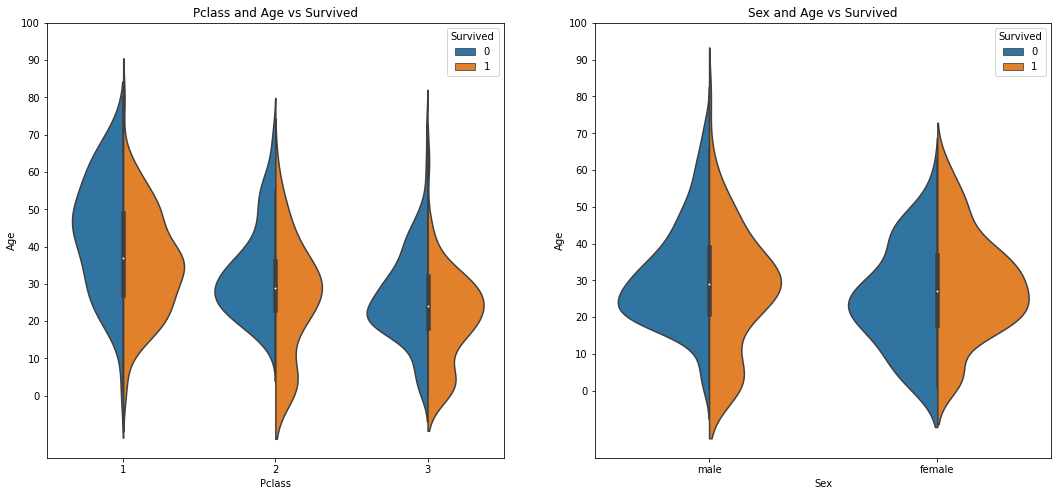

In [21]:
f, ax = plt.subplots(1, 2, figsize=(18, 8))
sns.violinplot(
    "Pclass", "Age", hue="Survived", data=titanic_train, split=True, ax=ax[0]
)
ax[0].set_title("Pclass and Age vs Survived")
ax[0].set_yticks(range(0, 110, 10))
sns.violinplot("Sex", "Age", hue="Survived", data=titanic_train, split=True, ax=ax[1])
ax[1].set_title("Sex and Age vs Survived")
ax[1].set_yticks(range(0, 110, 10))
plt.show()

<div style="font-size:18px; font-family:Georgia;">
Observations:
<ol style=“list-style-type:circle;”>
<li>The number of children increases with Pclass and the survival rate for passenegers below Age 10(i.e children) looks to be good irrespective of the Pclass.</li>
<li>Survival chances for Passenegers aged 20-50 from Pclass1 is high and is even better for Women.</li>
<li>For males, the survival chances decreases with an increase in age.</li>
</ol>
</div>

<div style="font-size:18px; font-family:Georgia;">
As previously stated, the Age feature has 177 null values. We can apply the mean age of the dataset to these NaN values to replace them.
<br>
However, there were numerous people of various ages present. We just cannot allocate a four-year-old to a family with a median age of 30 years. Is it possible to determine the passenger's age range?
<br>
We may now test the Name feature. We can observe from the characteristic that the names have a salutation, such as Mr. or Mrs. As a result, we can allocate the mean values of Mr and Mrs to the appropriate categories.
</div>

In [22]:
titanic_train["Initial"] = 0
titanic_test["Initial"] = 0

for i in titanic_train:
    titanic_train["Initial"] = titanic_train.Name.str.extract(
        "([A-Za-z]+)\."
    )  # lets extract the Salutations

for i in titanic_test:
    titanic_test["Initial"] = titanic_test.Name.str.extract(
        "([A-Za-z]+)\."
    )  # lets extract the Salutations

In [23]:
pd.crosstab(titanic_train.Initial, titanic_train.Sex).T.style.background_gradient(
    cmap="summer_r"
)  # Checking the Initials with the Sex

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Sex,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [24]:
pd.crosstab(titanic_test.Initial, titanic_test.Sex).T.style.background_gradient(
    cmap="summer_r"
)

Initial,Col,Dona,Dr,Master,Miss,Mr,Mrs,Ms,Rev
Sex,,,,,,,,,
female,0,1,0,0,78,0,72,1,0
male,2,0,1,21,0,240,0,0,2


<div style="font-size:18px; font-family:Georgia;">
There are some misspelled Initials like Mlle or Mme that stand for Miss. I will replace them with Miss and same thing for other values.
</div>

In [25]:
titanic_train["Initial"].replace(
    [
        "Mlle",
        "Mme",
        "Ms",
        "Dr",
        "Major",
        "Lady",
        "Countess",
        "Jonkheer",
        "Col",
        "Rev",
        "Capt",
        "Sir",
        "Don",
    ],
    [
        "Miss",
        "Miss",
        "Miss",
        "Mr",
        "Mr",
        "Mrs",
        "Mrs",
        "Other",
        "Other",
        "Other",
        "Mr",
        "Mr",
        "Mr",
    ],
    inplace=True,
)

In [26]:
titanic_test["Initial"].replace(
    ["Col", "Dona", "Dr", "Master", "Miss", "Mr", "Mrs", "Ms", "Rev"],
    ["Other", "Mr", "Mr", "Mr", "Mrs", "Mr", "Mrs", "Mrs", "Mr"],
    inplace=True,
)

In [27]:
titanic_train.groupby("Initial")["Age"].mean()  # lets check the average age by Initials

Initial
Master     4.574167
Miss      21.860000
Mr        32.739609
Mrs       35.981818
Other     45.888889
Name: Age, dtype: float64

In [28]:
titanic_test.groupby("Initial")["Age"].mean()  # lets check the average age by Initials

Initial
Mr       30.122108
Mrs      30.203095
Other    50.000000
Name: Age, dtype: float64

<div style="font-size:18px; font-family:Georgia;">Now let's fill nan values</div>

In [29]:
## Assigning the NaN Values with the Ceil values of the mean ages
titanic_train.loc[
    (titanic_train.Age.isnull()) & (titanic_train.Initial == "Mr"), "Age"
] = 33
titanic_train.loc[
    (titanic_train.Age.isnull()) & (titanic_train.Initial == "Mrs"), "Age"
] = 36
titanic_train.loc[
    (titanic_train.Age.isnull()) & (titanic_train.Initial == "Master"), "Age"
] = 5
titanic_train.loc[
    (titanic_train.Age.isnull()) & (titanic_train.Initial == "Miss"), "Age"
] = 22
titanic_train.loc[
    (titanic_train.Age.isnull()) & (titanic_train.Initial == "Other"), "Age"
] = 46

In [30]:
titanic_test.loc[
    (titanic_test.Age.isnull()) & (titanic_test.Initial == "Mr"), "Age"
] = 30
titanic_test.loc[
    (titanic_test.Age.isnull()) & (titanic_test.Initial == "Mrs"), "Age"
] = 30
titanic_test.loc[
    (titanic_test.Age.isnull()) & (titanic_test.Initial == "Other"), "Age"
] = 50

In [31]:
titanic_train.drop(columns=["Name", "Initial"], axis=1, inplace=True)
titanic_test.drop(columns=["Name", "Initial"], axis=1, inplace=True)

In [32]:
titanic_train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [33]:
titanic_test.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Embarked       0
dtype: int64

<div style="font-size:18px; font-family:Georgia;">
    All null values are removed.
</div>

In [34]:
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


<div style="font-size:18px; font-family:Georgia;">Visualize some data.</div>

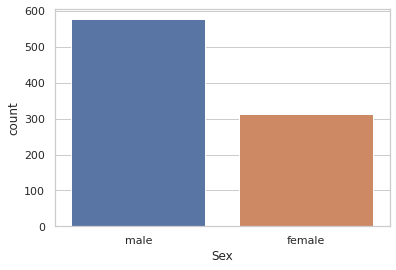

In [35]:
sns.set_theme(style="whitegrid")
sns.countplot(x=titanic_train["Sex"])
plt.show()

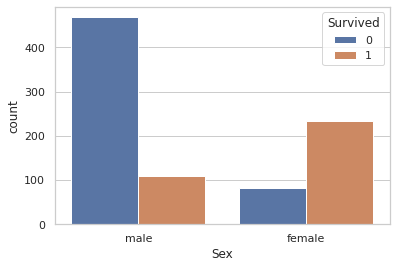

In [36]:
sns.countplot(data=titanic_train, x="Sex", hue="Survived")
plt.show()

<div style="font-size:18px; font-family:Georgia;">
From the countplot for survived passangers we can see that the number of female psurvivor assangers is more as compared to the male ones.<br>
And the reason is the obvious as during a calamity we often tend to save children and women.🫡<br>
So the plot seems to be obvious.
</div>

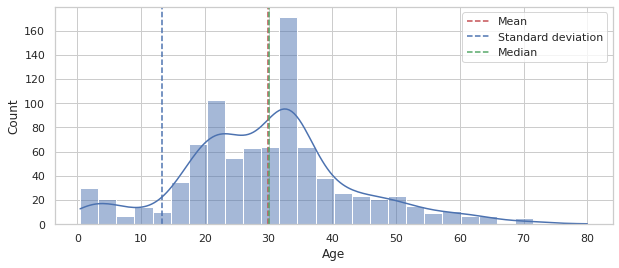

In [37]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=titanic_train, x="Age", kde=True)
ax.axvline(x=titanic_train["Age"].mean(), ls="--", color="r", label="Mean")
ax.axvline(x=titanic_train["Age"].std(), ls="--", color="b", label="Standard deviation")
ax.axvline(x=titanic_train["Age"].median(), ls="--", color="g", label="Median")
plt.legend()
plt.show()

<div style="font-size:18px; font-family:Georgia;">
The density distribution of the attribiute age shows us that majority of the passengers belinged to the age group of 25 to 35.<br>
</div>

In [38]:
# sns.pairplot(titanic_train)
# plt.show()
# titanic_train.isnull().sum()

In [39]:
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline

label = LabelEncoder()
titanic_train["Embarked"] = label.fit_transform(titanic_train["Embarked"])
titanic_test["Embarked"] = label.fit_transform(titanic_test["Embarked"])

<div style="font-size:18px; font-family:Georgia;">Encoding of Sex variable.</div>

In [40]:
titanic_train.replace({"Sex": {"male": 0, "female": 1}}, inplace=True)
titanic_test.replace({"Sex": {"male": 0, "female": 1}}, inplace=True)

<div style="font-size:18px; font-family:Georgia;">Dropping of Ticket and PassengerId attribute.</div>

In [41]:
passenger = titanic_test["PassengerId"]

In [42]:
titanic_train.drop("Ticket", axis=1, inplace=True)
titanic_test.drop("Ticket", axis=1, inplace=True)
titanic_train.drop(["PassengerId"], axis=1, inplace=True)
titanic_test.drop(["PassengerId"], axis=1, inplace=True)

In [43]:
titanic_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,0,35.0,0,0,8.0500,2


In [44]:
# sns.histplot(data=np.log1p(titanic_test["Fare"]), kde=True)

In [45]:
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [46]:
titanic_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    int64  
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      417 non-null    float64
 6   Embarked  418 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 23.0 KB


In [47]:
titanic_test.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        1
Embarked    0
dtype: int64

In [48]:
titanic_test["Fare"].fillna(
    value=titanic_test["Fare"].mean(), inplace=True
)  # only 1 null value so drop

In [49]:
# titanic_train.drop(['PassengerId'], axis = 1, inplace=True)
# titanic_test.drop(['PassengerId'], axis = 1, inplace=True)

In [50]:
y = titanic_train["Survived"]
titanic_train.drop(["Survived"], axis=1, inplace=True)

In [51]:
X = titanic_train

In [52]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:center;display:fill;border-radius:5px;background-color:#4285F4;overflow:hidden">Feature Engineering</div>

<div style="font-size:18px; font-family:Georgia;">
Before moving on to the model building part I will perform some feature engineering.<br>
To begin with I will normalize the Age attribute.<br>
Next, as we saw previously the Fare attribute is left skewed, so instead of applying normalization I will use log1p transformation.
</div>

In [53]:
# standardize Fare column
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

std = StandardScaler()
X[["Age"]] = std.fit_transform(X[["Age"]])
titanic_test[["Age"]] = std.fit_transform(titanic_test[["Age"]])

In [54]:
X[["Fare"]] = np.log1p(X[["Fare"]])
titanic_test[["Fare"]] = np.log1p(titanic_test[["Fare"]])

# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:center;display:fill;border-radius:5px;background-color:#4285F4;overflow:hidden">Using Logistic regression</div>

In [55]:
# clf2 = SVC(probability=True, random_state=42)
logreg = LogisticRegression(tol=1e-6, penalty="l2", random_state=42, solver="lbfgs")
param = {"C": [0.001, 0.01, 0.1, 1], "max_iter": [100, 300, 500]}


grid = GridSearchCV(logreg, param, cv=10, return_train_score=True)

In [56]:
grid.fit(X, y.ravel())

GridSearchCV(cv=10, estimator=LogisticRegression(random_state=42, tol=1e-06),
             param_grid={'C': [0.001, 0.01, 0.1, 1],
                         'max_iter': [100, 300, 500]},
             return_train_score=True)

In [57]:
grid.best_params_

{'C': 0.1, 'max_iter': 100}

In [58]:
grid.best_score_

0.7935330836454433

# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:center;display:fill;border-radius:5px;background-color:#4285F4;overflow:hidden">Use SVM</div>

In [59]:
svm = svm.SVC(probability=True, random_state=42)

param2 = {
    "kernel": ["linear", "rbf", "sigmoid"],
    "gamma": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "C": [0.05, 0.1, 0.2, 0.3, 0.25, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
}

grid_svm = GridSearchCV(svm, param2, cv=10, return_train_score=True)

In [60]:
grid_svm.fit(X, y.ravel())

GridSearchCV(cv=10, estimator=SVC(probability=True, random_state=42),
             param_grid={'C': [0.05, 0.1, 0.2, 0.3, 0.25, 0.4, 0.5, 0.6, 0.7,
                               0.8, 0.9, 1],
                         'gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
                                   1.0],
                         'kernel': ['linear', 'rbf', 'sigmoid']},
             return_train_score=True)

In [61]:
grid_svm.best_params_

{'C': 0.4, 'gamma': 0.2, 'kernel': 'rbf'}

In [62]:
grid_svm.best_score_

0.8260299625468164

# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:center;display:fill;border-radius:5px;background-color:#4285F4;overflow:hidden">Use Random Forest</div>

In [63]:
rf = RandomForestClassifier(random_state=42)

param3 = {"n_estimators": [100, 150, 200], "criterion": ["gini", "entropy", "log_loss"]}

rf_grid = GridSearchCV(rf, param3, cv=10, return_train_score=True)

In [64]:
rf_grid.fit(X, y.ravel())

GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'n_estimators': [100, 150, 200]},
             return_train_score=True)

In [65]:
rf_grid.best_params_

{'criterion': 'gini', 'n_estimators': 100}

In [66]:
rf_grid.best_score_

0.8115106117353307

# <div style="padding:20px;color:white;margin:0;font-size:30px;font-family:Georgia;text-align:center;display:fill;border-radius:5px;background-color:#4285F4;overflow:hidden">Submission</div>

In [67]:
titanic_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,0.339424,0,0,2.178064,1
1,3,1,1.329924,1,0,2.079442,2
2,2,0,2.518523,0,0,2.369075,1
3,3,0,-0.254876,0,0,2.268252,2
4,3,1,-0.651076,1,1,2.586824,2
...,...,...,...,...,...,...,...
413,3,0,-0.017156,0,0,2.202765,2
414,1,1,0.696004,0,0,4.699571,0
415,3,0,0.656384,0,0,2.110213,2
416,3,0,-0.017156,0,0,2.202765,2


In [68]:
# titanic_test.isnull().sum()
y_hat = grid_svm.predict(titanic_test)

In [69]:
y_hat.shape[0] == titanic_test.shape[0]

True

In [70]:
passenger.shape[0] == y_hat.shape[0]

True

In [71]:
df2 = pd.DataFrame({"PassengerId": passenger, "Survived": y_hat})

In [72]:
df2.to_csv("submission.csv", index=False)